Saved snapshot: error_propagation_snapshot.png


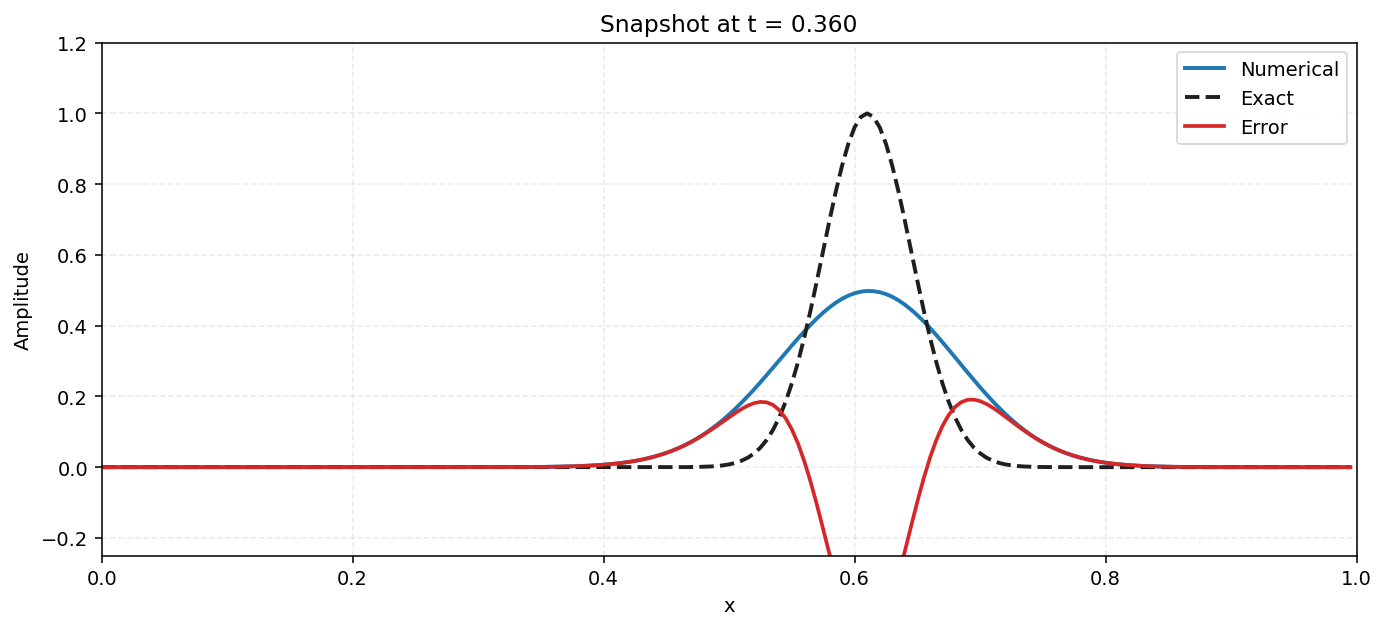

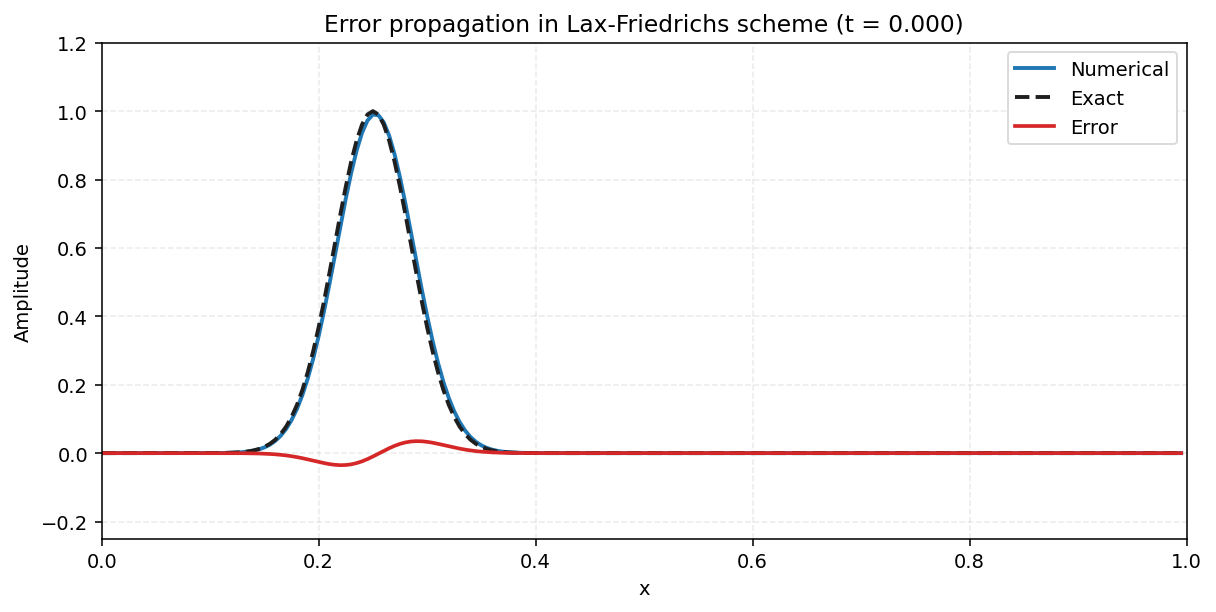

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SIZE = 200
L = 1.0
dx = L / SIZE
x = np.linspace(0, L, SIZE, endpoint=False)

c = 1.0
dt = 0.4 * dx / c  # CFL condition
maxTime = 600
sigma = 0.05
x0 = 0.25

u0 = np.exp(-((x - x0) ** 2) / sigma**2)
u = u0.copy()


def exact_solution(x, t):
    pos = (x - x0 - c * t) % L
    res = np.zeros_like(x)
    for shift in (-L, 0, L):
        res += np.exp(-((pos - shift) ** 2) / sigma**2)
    return res


def lax_friedrichs(u):
    u_right = np.roll(u, -1)
    u_left = np.roll(u, 1)
    return 0.5 * (u_right + u_left) - 0.5 * c * dt / dx * (u_right - u_left)


def evolve_n_steps(u_start, n_steps):
    u_now = u_start.copy()
    for _ in range(n_steps):
        u_now = lax_friedrichs(u_now)
    return u_now


snapshot_step = 180
t_snapshot = snapshot_step * dt
u_snapshot = evolve_n_steps(u0, snapshot_step)
u_exact_snapshot = exact_solution(x, t_snapshot)
err_snapshot = u_snapshot - u_exact_snapshot

fig_snap, ax_snap = plt.subplots(figsize=(10, 4.6), dpi=140)
ax_snap.plot(x, u_snapshot, label="Numerical", color="#1f77b4", lw=2.0)
ax_snap.plot(x, u_exact_snapshot, "--", label="Exact", color="#1f1f1f", lw=2.0)
ax_snap.plot(x, err_snapshot, label="Error", color="#d62728", lw=1.9)
ax_snap.set_xlim(0, L)
ax_snap.set_ylim(-0.25, 1.2)
ax_snap.set_xlabel("x")
ax_snap.set_ylabel("Amplitude")
ax_snap.set_title(f"Snapshot at t = {t_snapshot:.3f}")
ax_snap.grid(alpha=0.25, linestyle="--")
ax_snap.legend(frameon=True, facecolor="white", edgecolor="#d9d9d9", framealpha=0.95)
fig_snap.tight_layout()
snapshot_path = "error_propagation_snapshot.png"
# fig_snap.savefig(snapshot_path, bbox_inches="tight")
# plt.show()
print(f"Saved snapshot: {snapshot_path}")

fig, ax = plt.subplots(figsize=(10, 4.6), dpi=140)
(line_num,) = ax.plot(x, u, label="Numerical", color="#1f77b4", lw=2.0)
(line_ex,) = ax.plot(x, exact_solution(x, 0), "--", label="Exact", color="#1f1f1f", lw=2.0)
(line_err,) = ax.plot(x, u - exact_solution(x, 0), label="Error", color="#d62728", lw=1.9)
ax.set_ylim(-0.25, 1.2)
ax.set_xlim(0, L)
ax.set_xlabel("x")
ax.set_ylabel("Amplitude")
ax.set_title("Error propagation in Lax-Friedrichs scheme")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=True, facecolor="white", edgecolor="#d9d9d9", framealpha=0.95)


def update(n):
    global u
    u = lax_friedrichs(u)
    t = n * dt
    u_ex = exact_solution(x, t)
    line_num.set_ydata(u)
    line_ex.set_ydata(u_ex)
    line_err.set_ydata(u - u_ex)
    ax.set_title(f"Error propagation in Lax-Friedrichs scheme (t = {t:.3f})")
    return line_num, line_ex, line_err


ani = animation.FuncAnimation(
    fig, update, frames=maxTime, interval=35, blit=False, repeat=False
)

EXPORT_GIF = False
if EXPORT_GIF:
    gif_path = "error_propagation.gif"
    writer = animation.PillowWriter(fps=20)
    ani.save(gif_path, writer=writer)
    print(f"Saved GIF: {gif_path}")


Output:![Error propagation animation](error_propagation.gif)